# News vendor problem

## Imports

In [1]:
from inventory_management.items import Item
from inventory_management.distributions.demand_distributions import NormalDemand, SampledDemand
from inventory_management.solvers import SingleItemSolver, MultiItemConstrainedSolver, ScipyOptimizationSolver

import numpy as np

## Single Item problem

### Normal Distribution

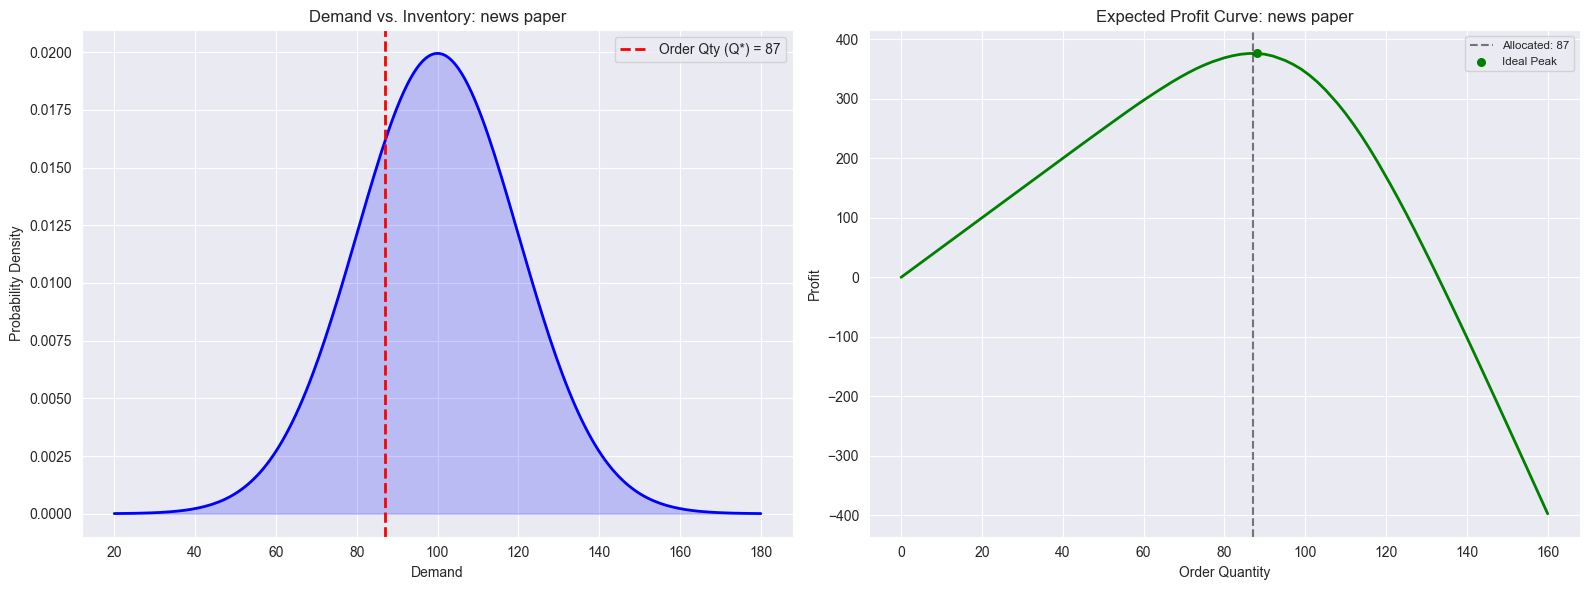

In [2]:
newspaper = Item(name="news paper", cost_price=30, selling_price=35, salvage_value=15)
demand = NormalDemand(mean=100, std_dev=20)
solver = SingleItemSolver(item=newspaper, demand_distribution=demand)

# solve
optimal_quantity = solver.solve()

# show results
from inventory_management.plot_suite.single_item import plot_single_item_analysis

results = plot_single_item_analysis(newspaper, demand, optimal_quantity)


### Sampled Distribution

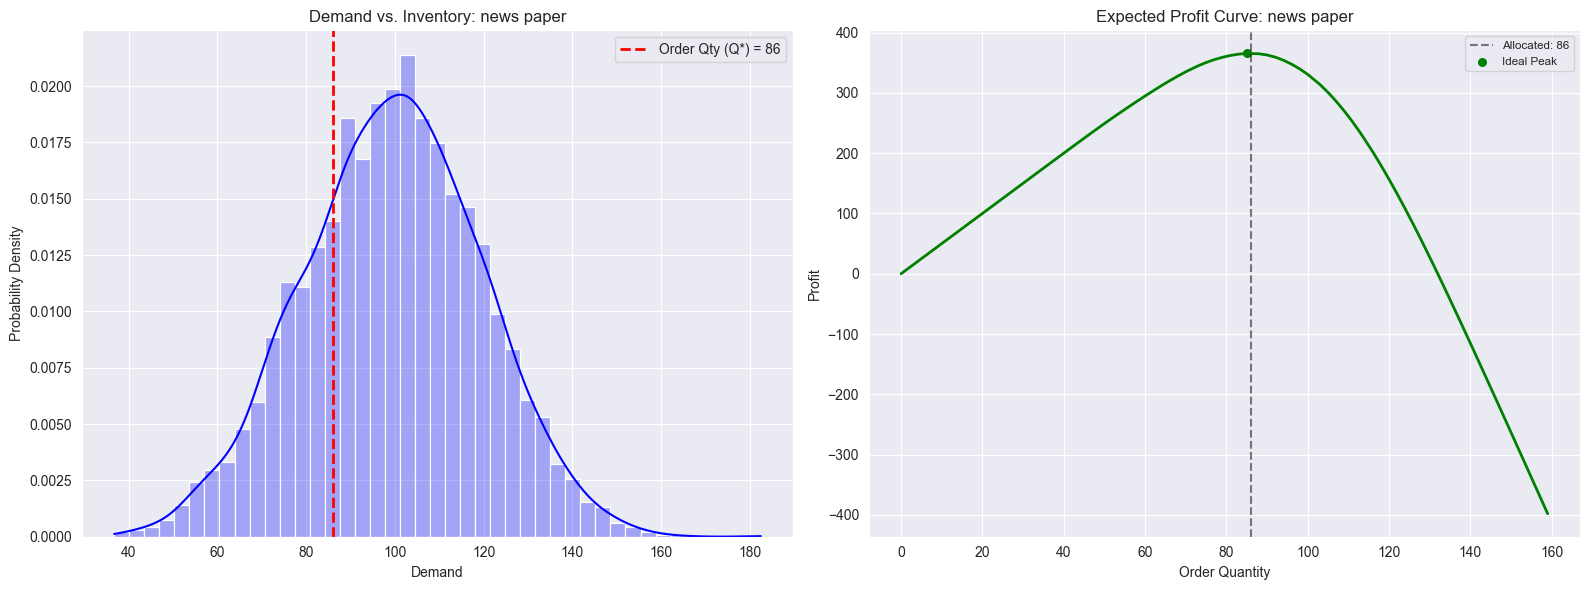

In [4]:
raw_trace_data = np.random.normal(loc=100, scale=20, size=(4, 1000))
    
# The class will handle the flattening of the (4, 1000) array automatically
demand = SampledDemand(samples=raw_trace_data)
solver = SingleItemSolver(item=newspaper, demand_distribution=demand)

# solve
optimal_quantity = solver.solve()

# show results
results = plot_single_item_analysis(newspaper, demand, optimal_quantity)


### Interactive dashboard

In [5]:
from inventory_management.plot_suite.interactive import create_item_dashboard

dash = create_item_dashboard(newspaper, demand)
dash

## Multiple Items (with constraint)

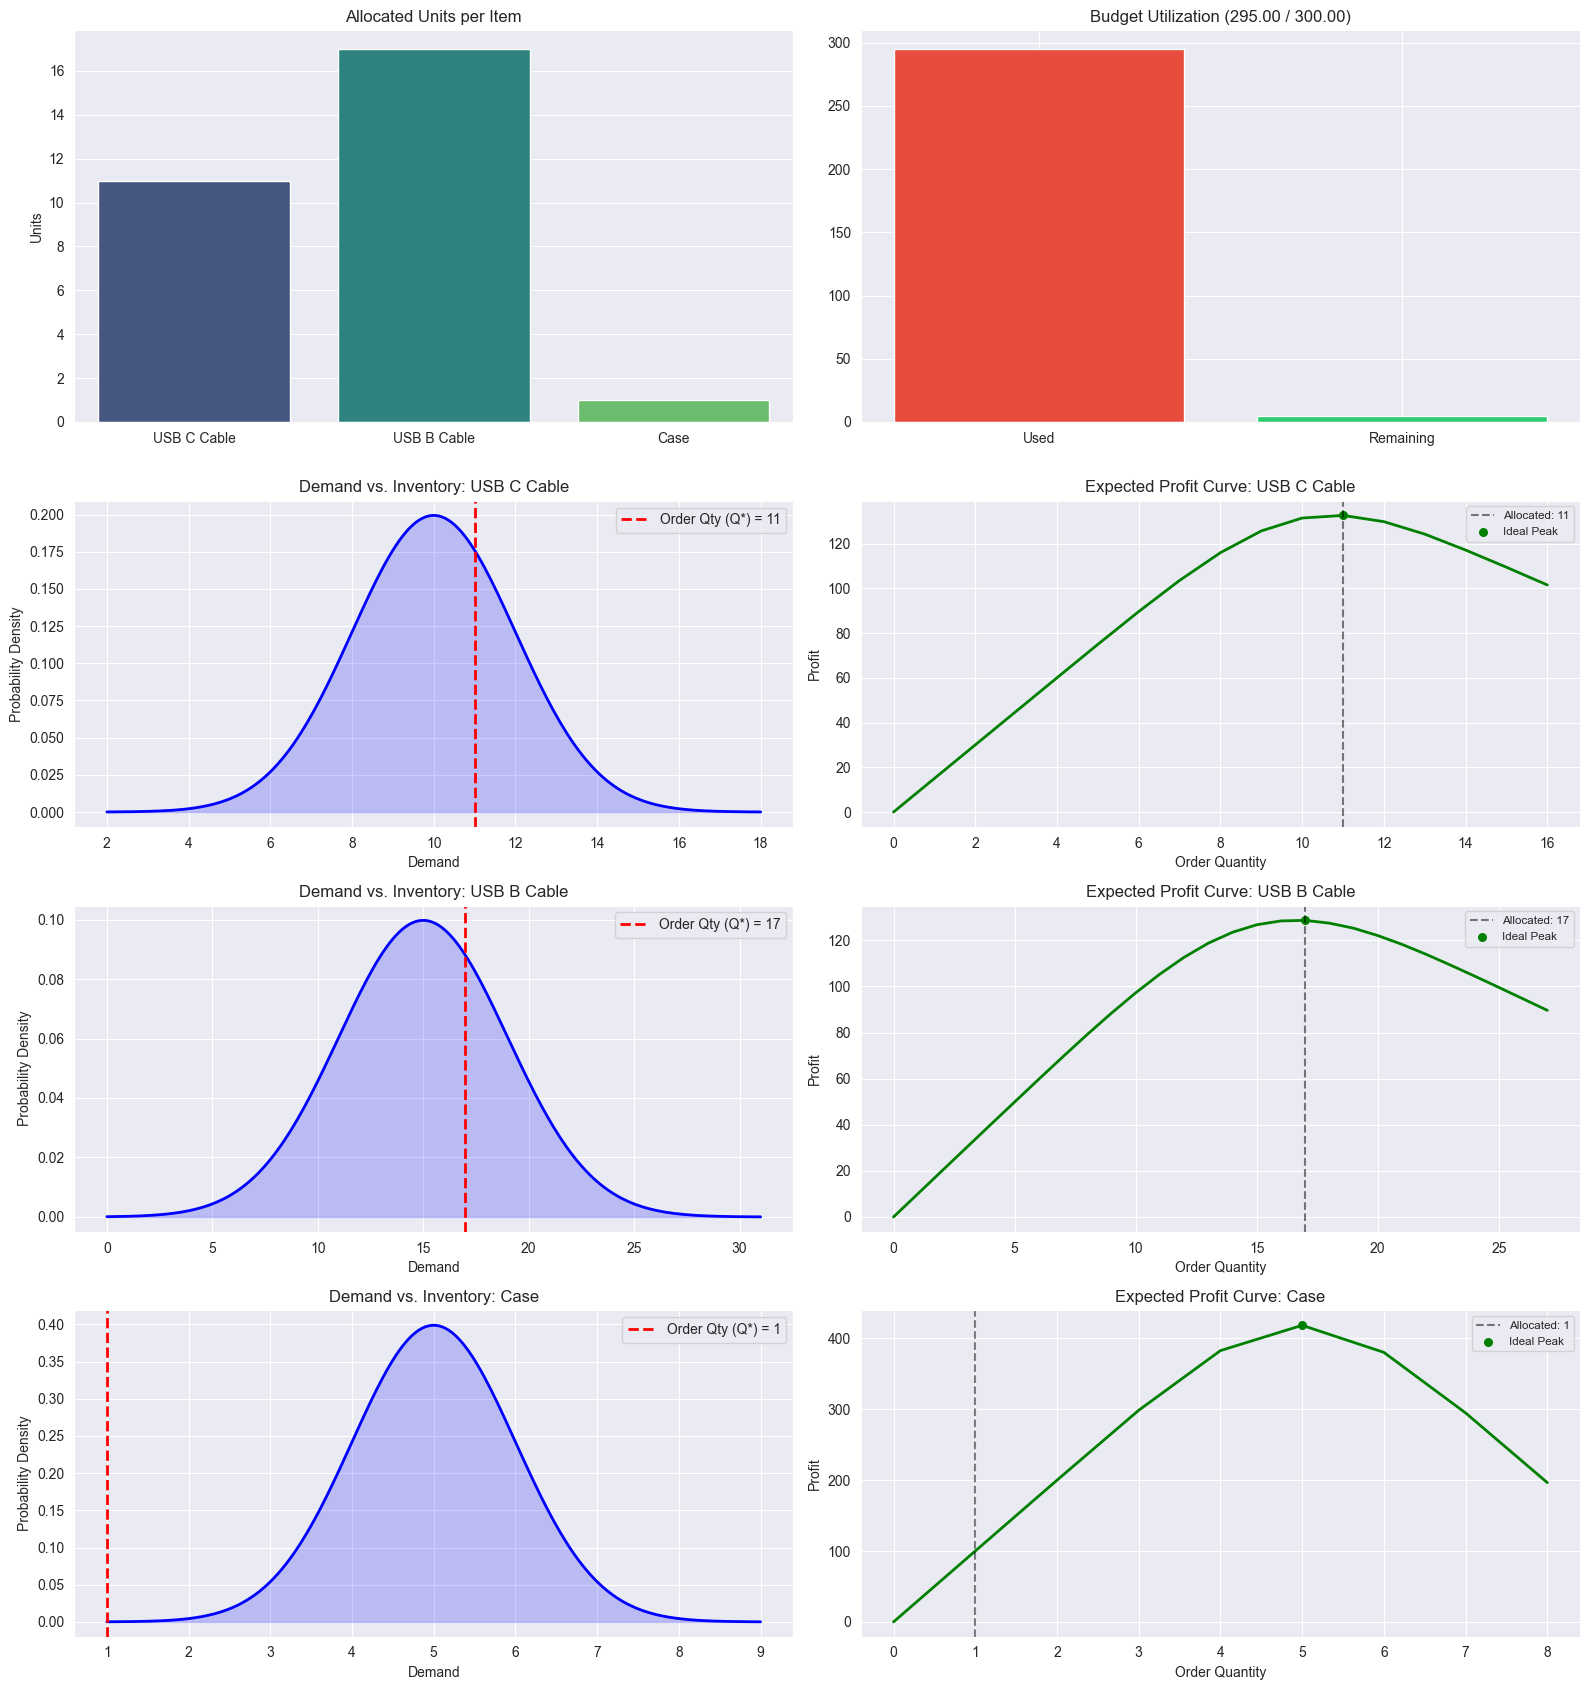

In [6]:
usb_C = Item("USB C Cable", 10, 25, 2)
usb_C_dem = NormalDemand(10, 2)

usb_B = Item("USB B Cable", 5, 15, 0)
usb_B_dem = NormalDemand(15, 4)

Case = Item("Case", 100, 200, 0)
Case_dem = NormalDemand(5, 1)

problems = [(usb_C, usb_C_dem), (usb_B, usb_B_dem), (Case, Case_dem)]

solver = MultiItemConstrainedSolver(problems, budget=300)
allocation = solver.solve()

# show results
from inventory_management.plot_suite.portfolio import plot_multi_item_allocation
results = plot_multi_item_allocation(allocation, problems, budget=300)


## Multiple Items and Constraints

c:\Users\bouwe\anaconda3\envs\inventory_env\Lib\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


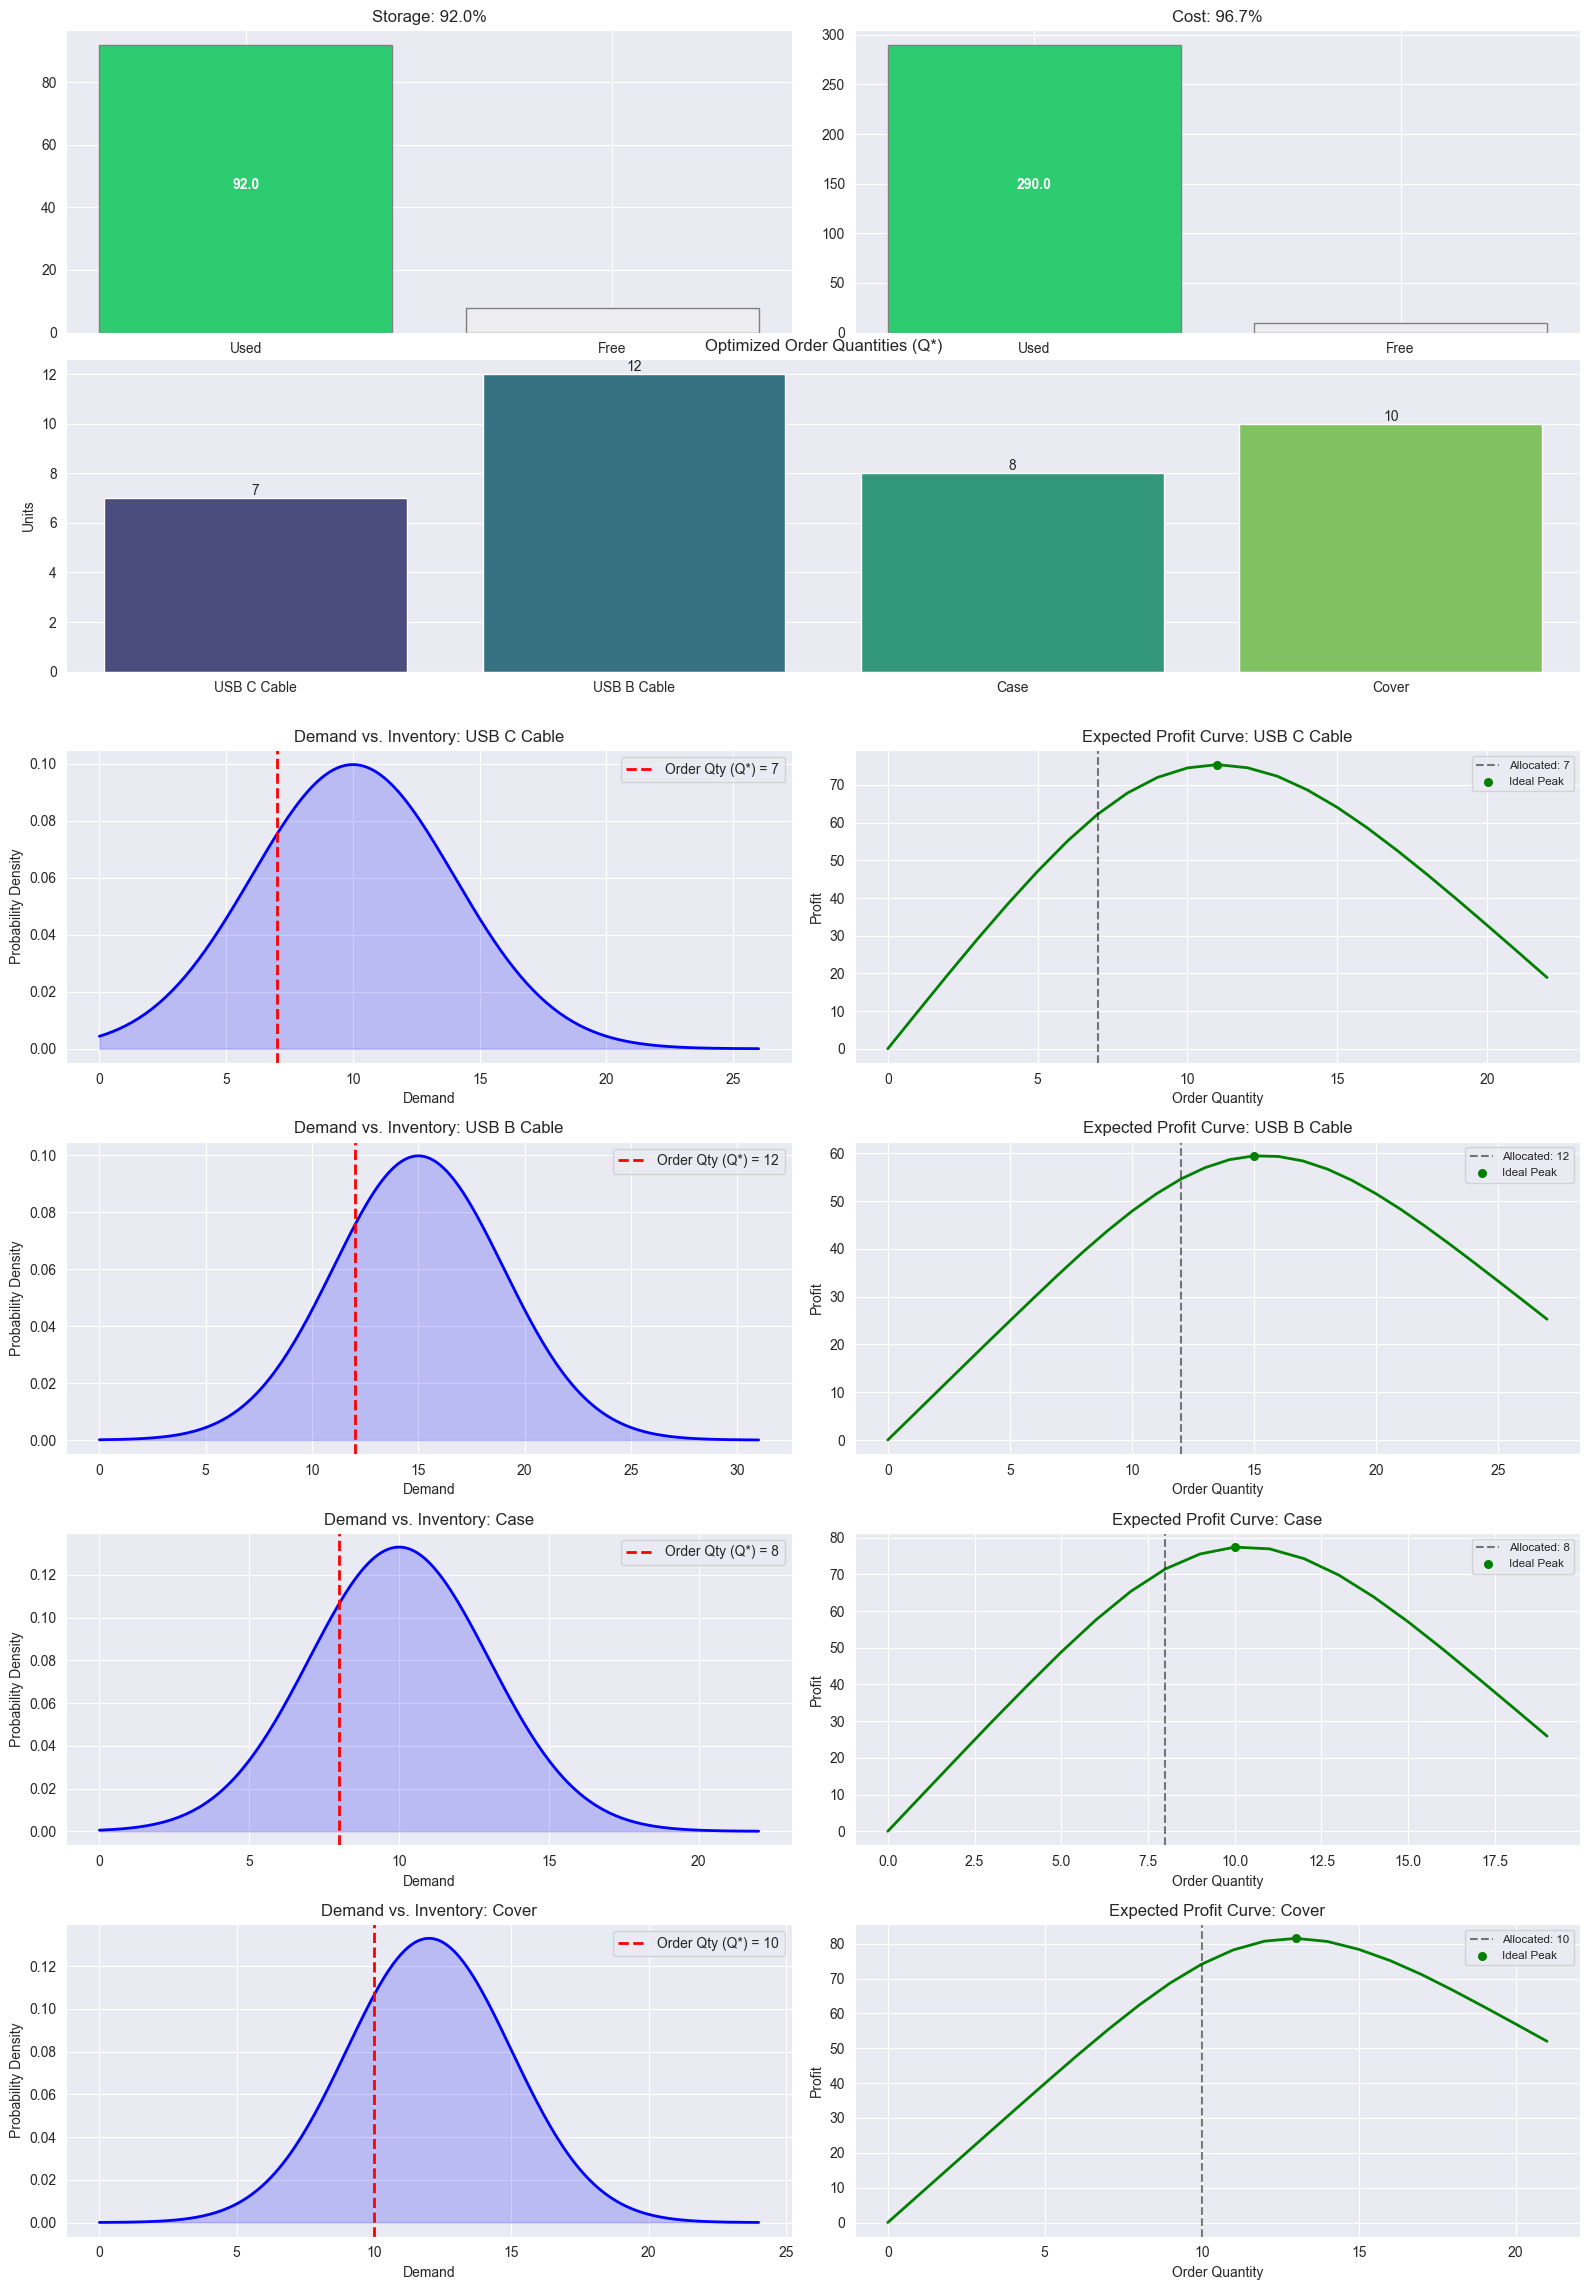

In [7]:
usb_C = Item("USB C Cable", 10, 20, 3, {"storage": 2, "cost": 10})
usb_C_dem = NormalDemand(10, 4)

usb_B = Item("USB B Cable", 5, 10, 1, {"storage": 2, "cost": 5})
usb_B_dem = NormalDemand(15, 4)

Case = Item("Case", 10, 20, 2, {"storage": 3, "cost": 10})
Case_dem = NormalDemand(10, 3)

Cover = Item("Cover", 8, 16, 3, {"storage": 3, "cost": 8})
Cover_dem = NormalDemand(12, 3)

problems = [
    (usb_C, usb_C_dem),
    (usb_B, usb_B_dem),
    (Case, Case_dem),
    (Cover, Cover_dem),
]

solver = ScipyOptimizationSolver(
    problems,
    limits={"storage": 100, "cost": 300},
)
allocation = solver.solve()

# show results
from inventory_management.plot_suite.portfolio import plot_constrained_allocation

results = plot_constrained_allocation(allocation, problems, solver.limits)


## View Optimized Results

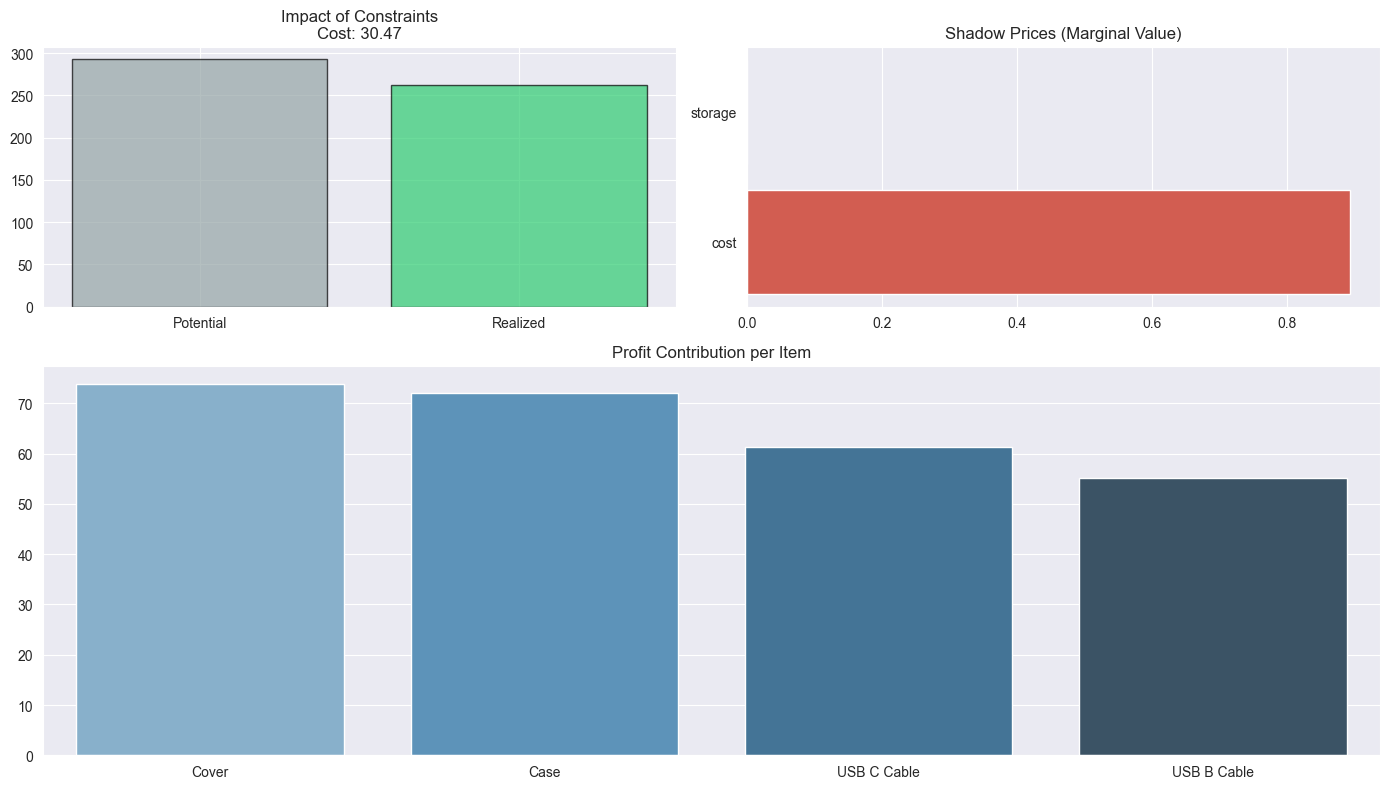

In [8]:
from inventory_management.plot_suite.portfolio import plot_optimization_summary
fig = plot_optimization_summary(allocation, problems, solver.lambdas)

## Stochastic Problems (Item quantity is also a distribution)

In [9]:
from inventory_management.distributions.yield_distributions import BetaYield
from inventory_management.solvers import StochasticMonteCarloSolver

chip = Item("Experimental Chip", 100, 200, 20, 
                constraints={'budget': 100},
                yield_distribution=BetaYield(1, 3))
chip_dem = NormalDemand(100, 20) 


resistor = Item("Standard Resistor", 10, 15, 2, 
                constraints={'budget': 10})
resistor_dem = NormalDemand(1000, 100)

problems = [(chip, chip_dem), (resistor, resistor_dem)]

limits = {'budget': 15000} 

# Risk Neutral (Maximize Average Profit)
solver = StochasticMonteCarloSolver(
    problems, limits, n_samples=5000,
)
res_neutral = solver.solve()
print(f"Risk Neutral Allocation (Lambda=0.0): {res_neutral}")

# Risk adverse
res_averse = solver.solve(risk_aversion = 5)
print(f"Risk Averse Allocation  (Lambda=0.9): {res_averse}")

# Analysis
chip_drop = res_neutral['Experimental Chip'] - res_averse['Experimental Chip']
print(f"\nImpact: The solver cut the Chip order by {chip_drop} units to reduce downside risk.")

Risk Neutral Allocation (Lambda=0.0): {'Experimental Chip': np.int64(0), 'Standard Resistor': np.int64(968)}
Risk Averse Allocation  (Lambda=0.9): {'Experimental Chip': np.int64(0), 'Standard Resistor': np.int64(960)}

Impact: The solver cut the Chip order by 0 units to reduce downside risk.


c:\Users\bouwe\anaconda3\envs\inventory_env\Lib\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\Users\bouwe\anaconda3\envs\inventory_env\Lib\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


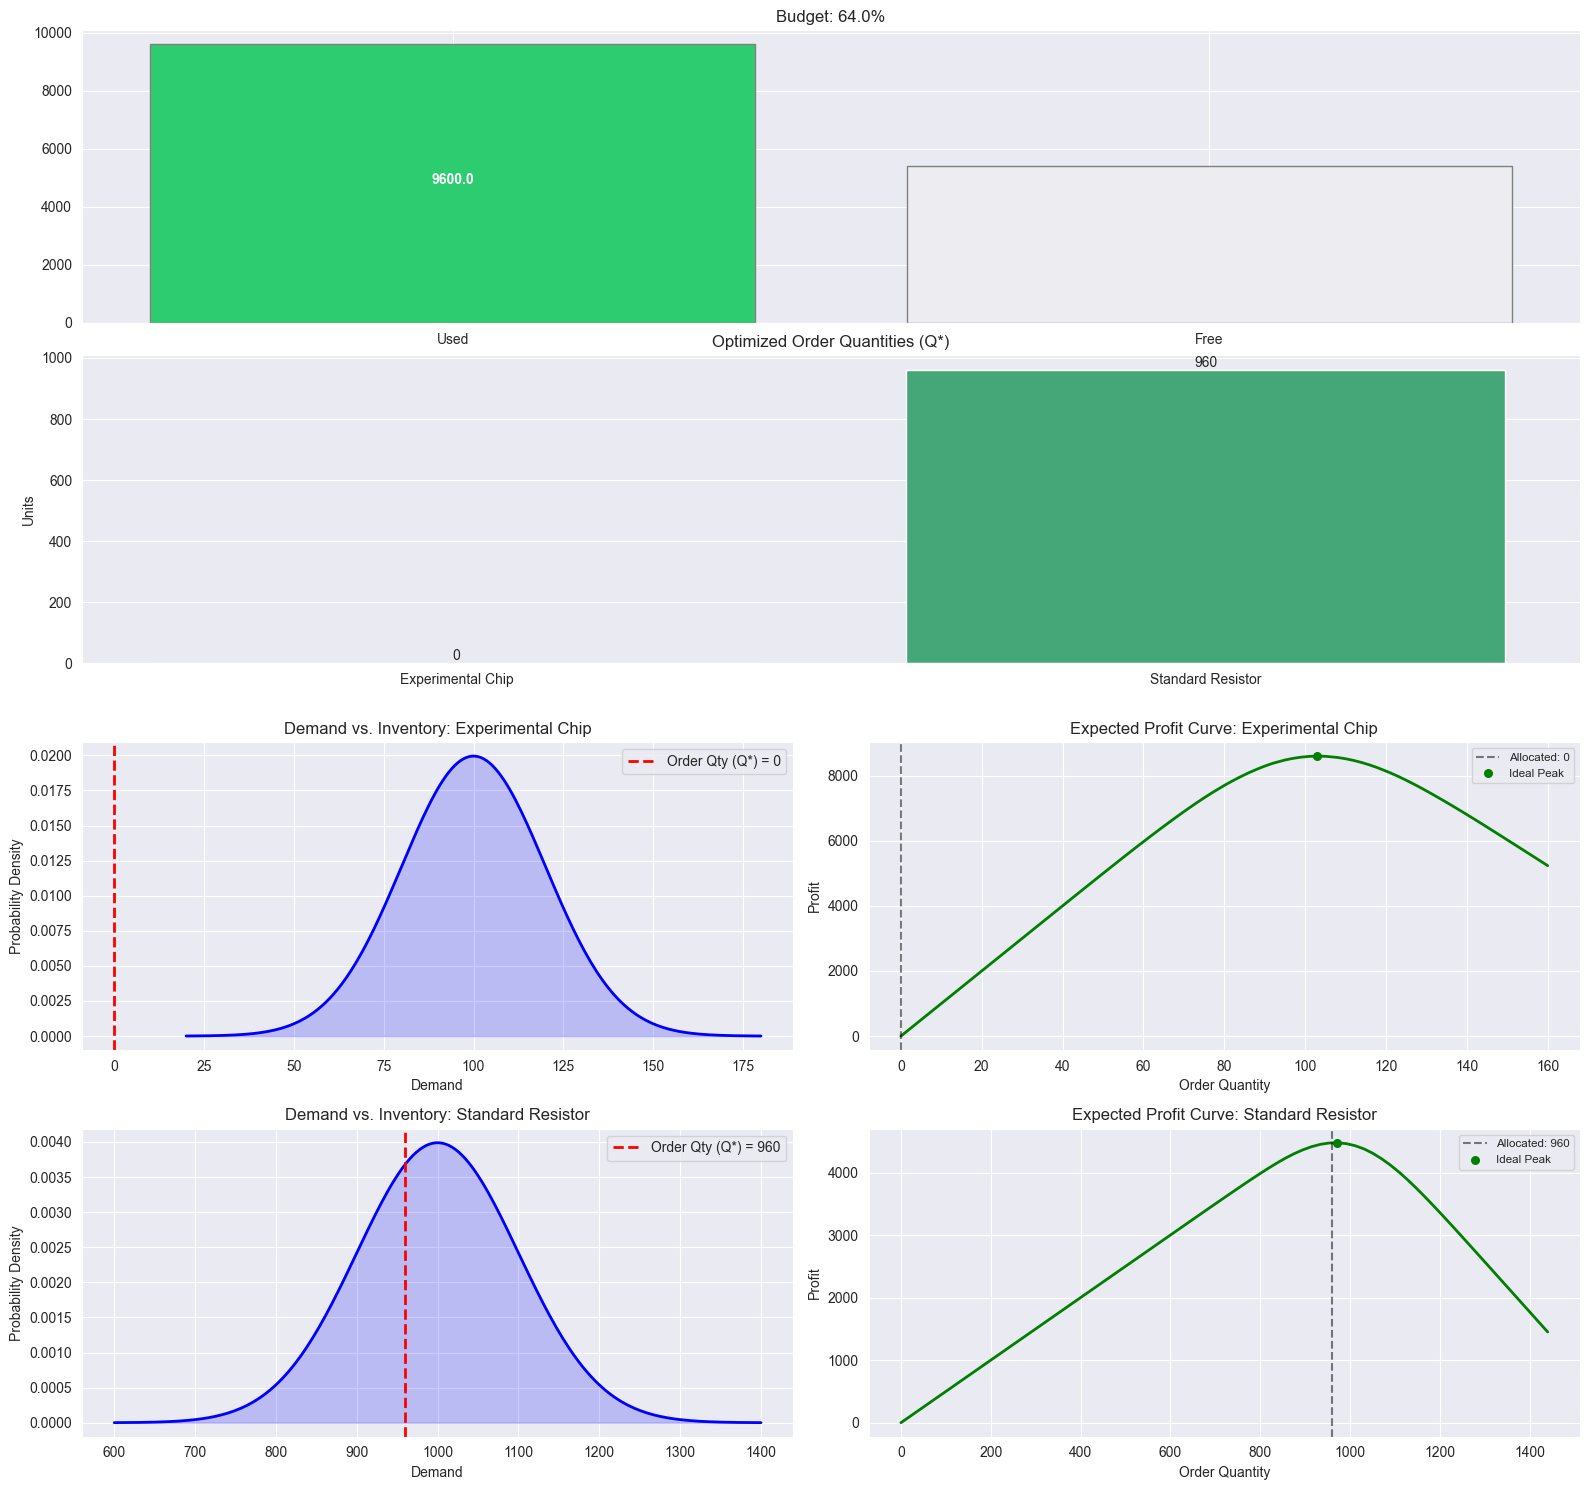

In [10]:
results = plot_constrained_allocation(
    res_averse, problems, solver.limits
)


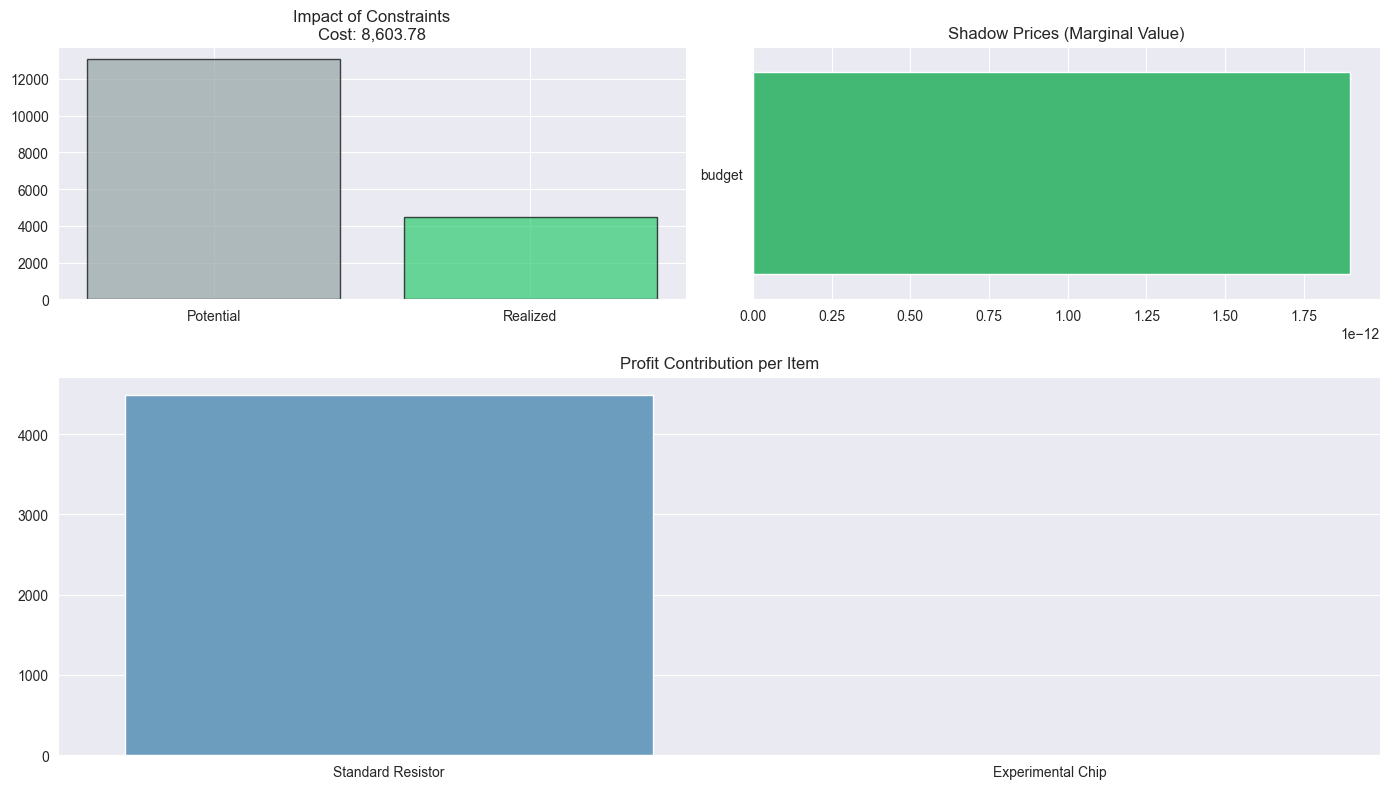

In [11]:
fig = plot_optimization_summary(res_averse, problems, solver.lambdas)

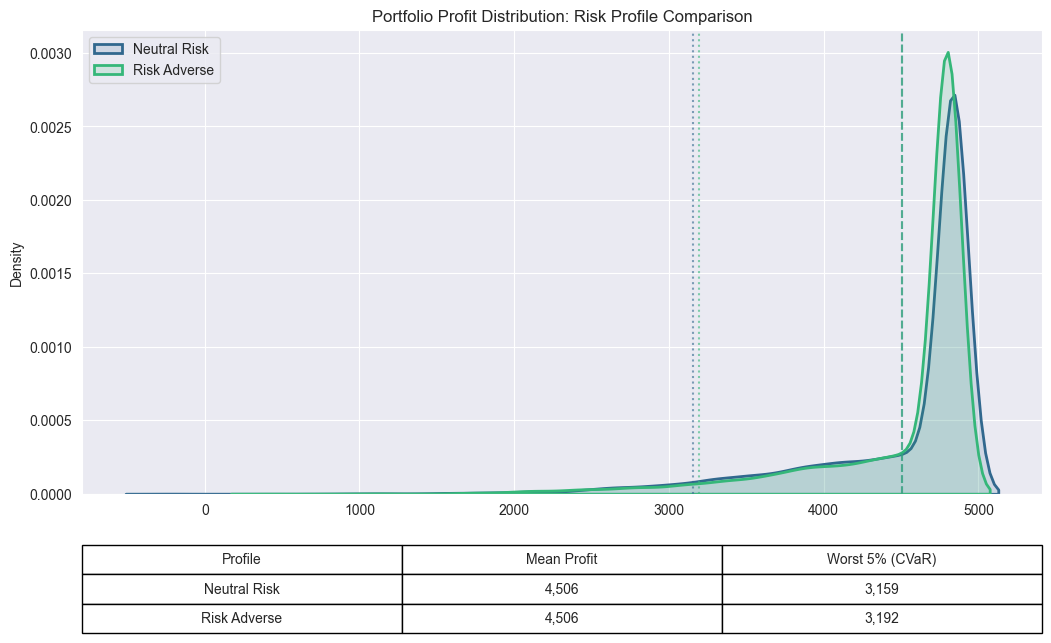

In [12]:
from inventory_management.plot_suite.risk import plot_risk_comparison
fig = plot_risk_comparison(
    {"Neutral Risk": res_neutral, "Risk Adverse": res_averse}, problems=problems
)

## Base Stock Problem

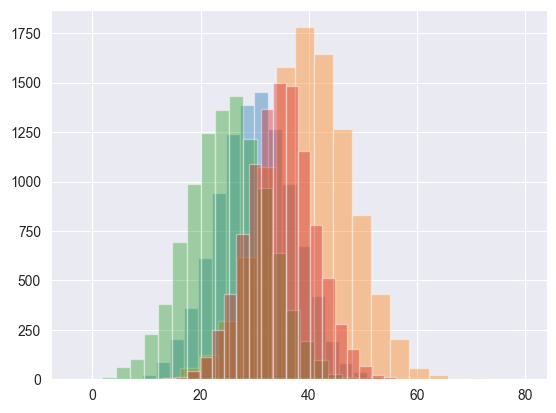

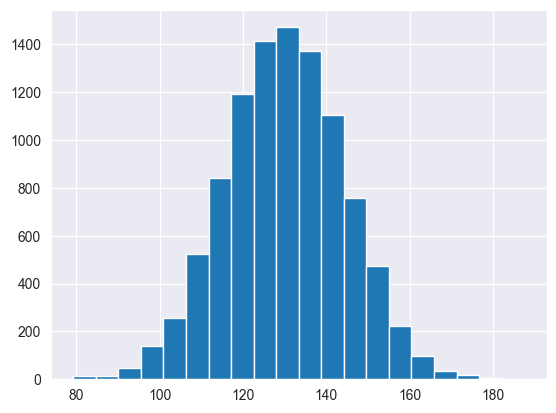

In [13]:
import matplotlib.pyplot as plt
from inventory_management.distributions.demand_distributions import demand_aggregator
demand = []
means = [30, 40, 25, 35]
stds = np.random.rand(4) * 5 + 3

fig, ax = plt.subplots()

for i in range(4):
    demand.append(NormalDemand(means[i], stds[i]))
    ax.hist(np.random.normal(demand[i].mean, demand[i].std, 10000), bins=20, alpha = 0.4)


demand_total = demand_aggregator(demand)
plt.figure()
plt.hist(np.random.normal(demand_total.mean, demand_total.std, 10000), bins=20)
plt.show()